# Using Transfer Learning and TensorFlow to Classify Different Dog Breeds

This project aims at using machine learning to help us identify dogs breeds.

Data from
[Kaggle dog breed identification competition](https://www.kaggle.com/c/dog-breed-identification/overview)
consists of a collection of 10,000+ labelled images of 120 different dog breeds.

This problem is multi-class image classification
since we're trying to classify mutliple different breeds of dog.\
If we were only trying to classify dogs versus cats, it'd be binary classification
(one thing versus another).

Multi-class image classification is an important problem because it's the same kind of technology
Tesla uses in their self-driving cars
or Airbnb uses in atuomatically adding information to their listings.

The most important step to start with in a deep learng problem is
getting the data ready (turning it into numbers).

Follow the TensorFlow/Deep Learning workflow:
1. Get data ready (download from Kaggle, store, import).
2. Prepare the data (preprocessing, the 3 sets, X & y).
3. Choose and fit/train a model ([TensorFlow Hub](https://www.tensorflow.org/hub),
   `tf.keras.applications`,
   [TensorBoard](https://www.tensorflow.org/tensorboard),
   [EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)).
4. Evaluating a model (making predictions, comparing them with the ground truth labels).
5. Improve the model through experimentation
   (start with 1000 images, make sure it works, increase the number of images).
6. Save, sharing and reloading your model (once you're happy with the results).

To prepare data, we use TensorFlow 2.x to get our data into Tensors
(arrays of numbers which can be run on GPUs)
and then allow a machine learning model to find patterns between them.

For our machine learning model, we use a pretrained deep learning model from TensorFlow Hub.

The process of using a pretrained model and adapting it to your own problem is called **transfer learning**.
We do this because rather than train our own model from scratch (could be timely and expensive),
we leverage the patterns of another model which has been trained to classify images.

## Setup workspace

Before we get started, let's impport TensorFlow 2.x and TensorFlow Hub (TensorFlow Hub)

**NOTE:** Don't run the cell below if you're already using TF 2.x.

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub


In [6]:
print("TF version:", tf.__version__)
try:
  # %tensorflow_version only exists in Colab
  %tensorflow_version 2.x
except Exception:
  pass

print("TF Hub version:", hub.__version__)

# Check for GPU availability
print("GPU", "available YES!" if tf.config.list_physical_devices("GPU") else "not available")

TF version: 2.18.0
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
TF Hub version: 0.16.1
GPU not available


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Get data ready (turning into Tensors)
With all machine learning models, data has to be in numerical format.
Converting images into Tensors.

Start with accessing data and checking the labels.

In [8]:
from typing import ClassVar
# Checkout the data labels
labels_csv = pd.read_csv("/content/drive/My Drive/Colab Notebooks/ZTM-AI/labels.csv")
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126 
------------------------------------------------------------

Median value: 82.0 
------------------------------------------------------------



<Axes: ylabel='breed'>

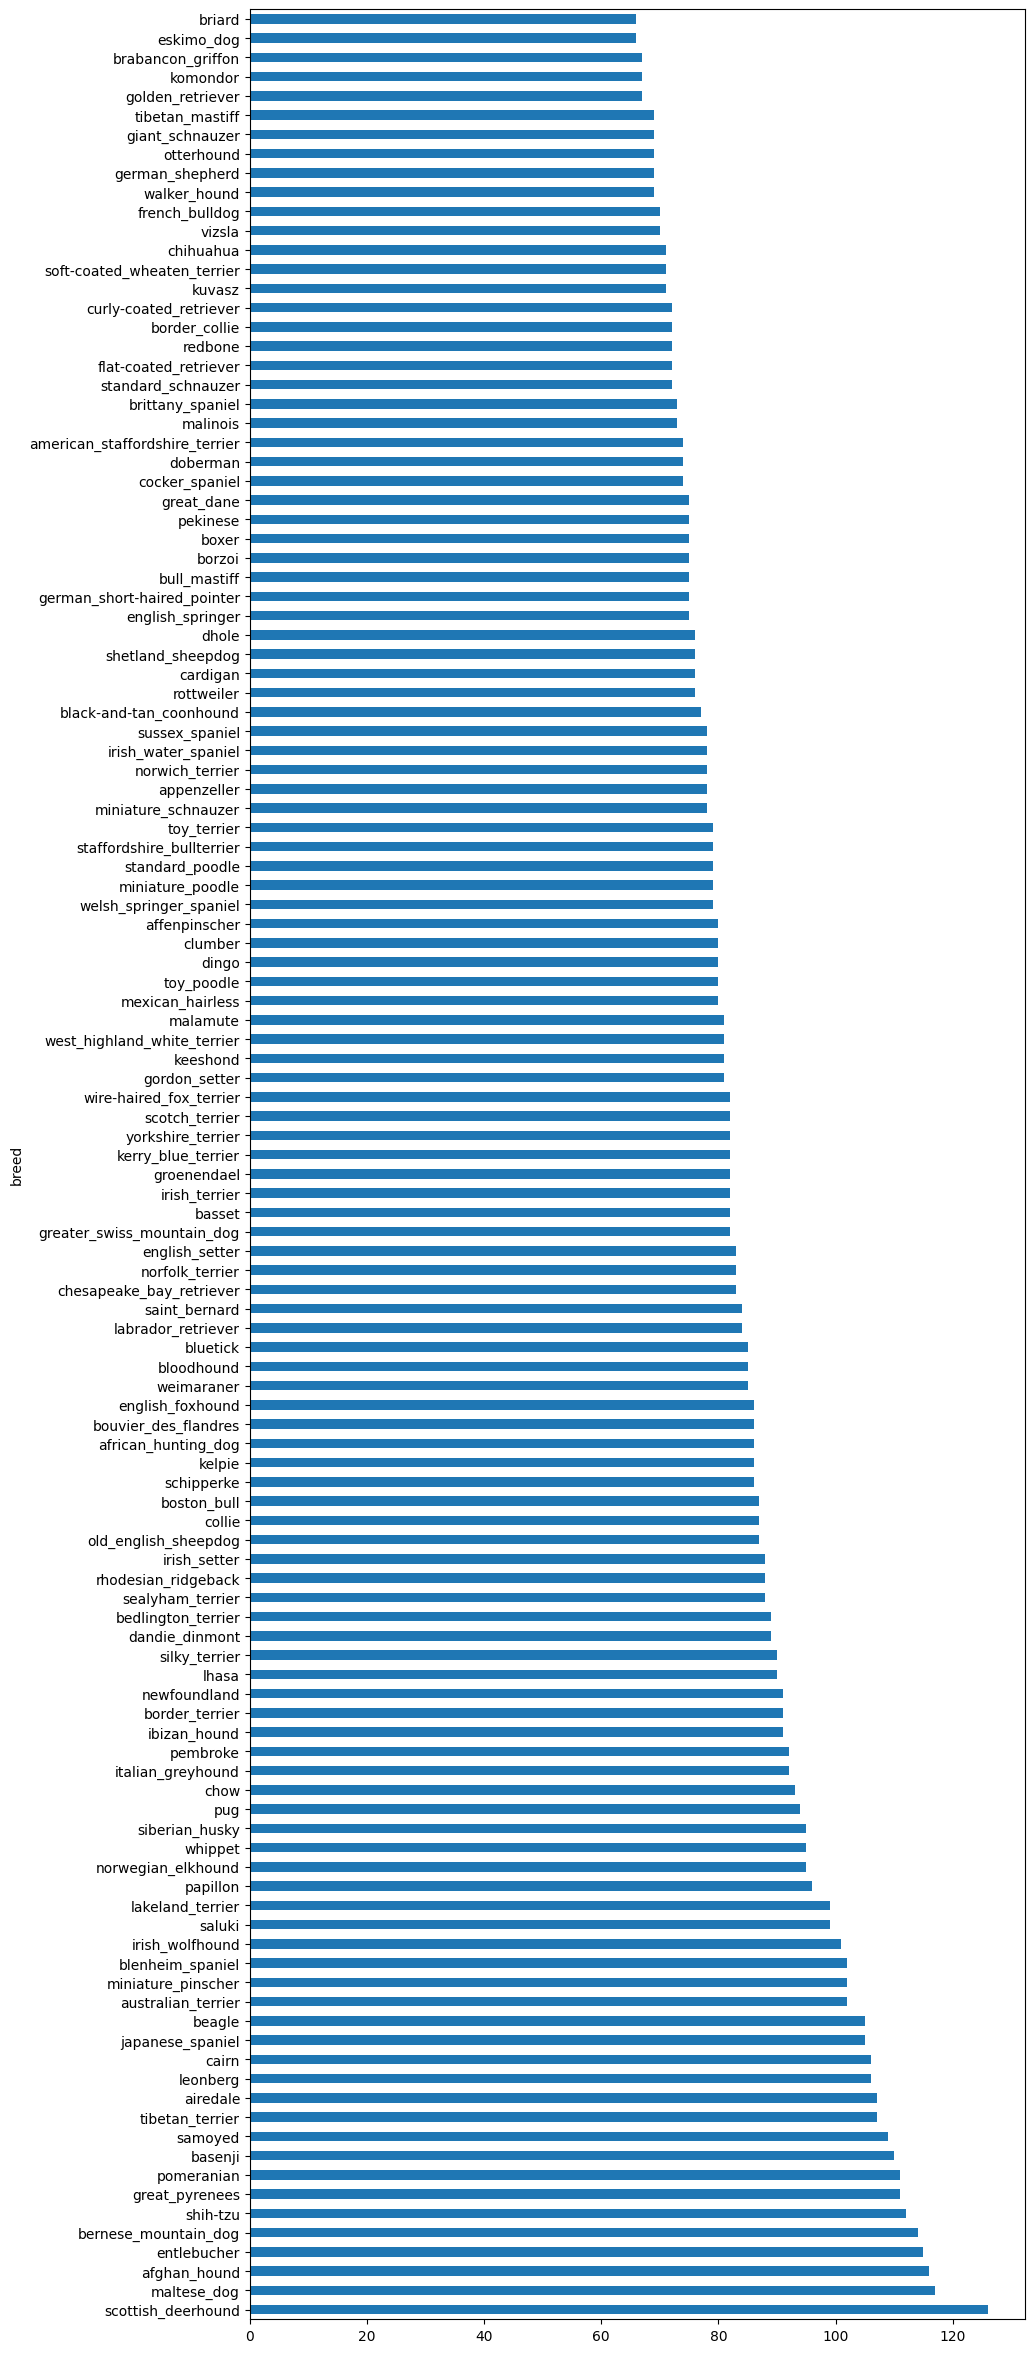

In [9]:
print(labels_csv.describe(),"\n------------------------------------------------------------\n")
print("Median value:", labels_csv["breed"].value_counts().median(),"\n------------------------------------------------------------\n")
# How many images are there of each bread?
labels_csv["breed"].value_counts().plot.barh(figsize=(10,30))

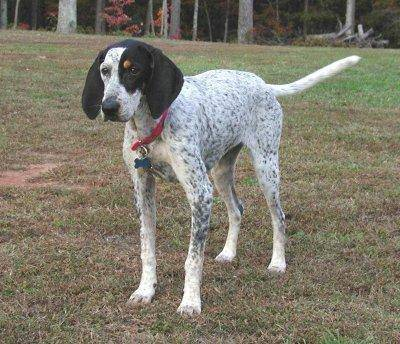

In [10]:
# View an image
from IPython.display import Image
Image("/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/00214f311d5d2247d5dfe4fe24b2303d.jpg")

### Get images and their labels
Get a list of all of the images file pathnames.

In [11]:
# Create pathnames from image IDs.
filepaths = ["/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/" + fname + ".jpg" for fname in labels_csv["id"]]
print(filepaths[:10])
# Check the number of filenames against the number of actual image files
import os
if len(os.listdir("/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/")) == len(labels_csv):
  print("Filepaths and labels 1-to-1 match!")
else:
  print("Filepaths and labels don't match!")

['/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/000bec180eb18c7604dcecc8fe0dba07.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/001cdf01b096e06d78e9e5112d419397.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/00214f311d5d2247d5dfe4fe24b2303d.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/0021f9ceb3235effd7fcde7f7538ed62.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/002211c81b498ef88e1b40b9abf84e1d.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/00290d3e1fdd27226ba27a8ce248ce85.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/002a283a315af96eaea0e28e7163b21b.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/003df8b8a8b05244b1d920bb6cf451f9.jpg', '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/0042188c895a2f14ef64a918ed9c7b64.jpg']
Filepaths and labels 1-to-1 match!


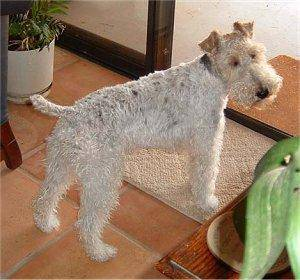

In [12]:
Image(filepaths[7000])

In [13]:
print(labels_csv.breed[7000], labels_csv.id[7000])

wire-haired_fox_terrier af750c18726a7dd02f0880a9bf662e31


In [14]:
# Prepare the labels
labels = labels_csv["breed"].to_numpy()
# Check the the number of labels
if len(labels) == len(labels_csv):
  print("Number of labels is the same as the number of filepaths")
else:
  print("Number of labels does not match the number of filepaths")

Number of labels is the same as the number of filepaths


In [15]:
# Find the unique label values
unique_breeds = np.unique(labels)
print("Unique bread:", len(unique_breeds))
# Trun a single label into an array of booleans
print(labels[0])
print(labels[0] == unique_breeds)

Unique bread: 120
boston_bull
[False False False False False False False False False False False False
 False False False False False False False  True False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]


In [16]:
# Turn every label into a boolean array
boolean_labels = [label == np.array(unique_breeds) for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [17]:
len(boolean_labels)

10222

In [21]:
# Example: Truning boolean array into integers
print(labels[0]) # Original label
print(np.where(unique_breeds == labels[0])[0][0]) # Index where label occurs
print(boolean_labels[0].argmax()) # Index where label occurs in boolean_labels array
print(boolean_labels[0].astype(int)) # There will be a 1 where the sample label occurs

boston_bull
19
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [22]:
print(labels[2]) # Original label
print(np.where(unique_breeds == labels[2])[0][0])# Index where label occurs
print(boolean_labels[2].argmax()) # Index where label occurs in boolean_labels array
print(boolean_labels[2].astype(int)) # There will be a 1 where the sample label occurs

pekinese
85
85
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


### Create our own validation set
Create our own validation set since Kaggle doesn't provide it.

In [24]:
# Setup X & y variables
X = filepaths
y = boolean_labels

We start experimenting with ~1000 images and increase per needed.

In [25]:
# Set number of images to use for experimenting
NUM_IMAGES = 1000 #@param {type: "slider", min:1000, max:10000, step:1000}

In [26]:
# Split data into train and validation sets
from sklearn.model_selection import train_test_split
np.random.seed(42)
# Split data into training and validation of total size NUM_IMAGES
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  test_size=0.2,
                                                  random_state=42)
len(X_train), len(y_train), len(X_val), len(y_val)

(800, 800, 200, 200)

In [27]:
# Take a look at the training data
X_train[:5], y_train[:2]

(['/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/00bee065dcec471f26394855c5c2f3de.jpg',
  '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/0d2f9e12a2611d911d91a339074c8154.jpg',
  '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/1108e48ce3e2d7d7fb527ae6e40ab486.jpg',
  '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/0dc3196b4213a2733d7f4bdcd41699d3.jpg',
  '/content/drive/My Drive/Colab Notebooks/ZTM-AI/train/146fbfac6b5b1f0de83a5d0c1b473377.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, Fals

## Preprocess images (convert images into Tensors)
Write a function to do a few things:
1. Take an image filepath as input
2. Use TensorFlow to read the file and save it to a variable, `image`
3. Convert the `image`(a jpg) into Tensors
4. Normaliz image by converting color channel values from 0-255 to 0-1
5. Resize the `image` to be a shape of (224, 224)
6. Return the modified `image`

Refer to
[TensorFlow load images](https://www.tensorflow.org/tutorials/load_data/images) and
[TensorFlow data pipeline](https://www.tensorflow.org/guide/data) for more details.

First, let's see what importing an image looks like.

In [28]:
# Convert image to Numpy
from matplotlib.pyplot import imread
image = imread(filepaths[42])
image.shape

(257, 350, 3)

In [29]:
image.max(), image.min()

(np.uint8(255), np.uint8(0))

In [32]:
image[:2]

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)

In [30]:
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

In [34]:
# Define image size
IMG_SIZE = 224
# Create a function for proprocessing images
def process_image(image_path, img_size=IMG_SIZE):
  """
  Take an image file path and covert the image into a Tensor.
  """
  # Read an image file
  image = tf.io.read_file(image_path)
  # Convert the jpeg image into numerical Tensors with 3 color channels (Red, Green, Blue)
  image = tf.image.decode_jpeg(image, channels=3)
  # Convert the color channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
  # Resize the image to our desired value (244, 244)
  image = tf.image.resize(image, size=[img_size, img_size])
  return image

## Turn the data into batches
Why turn data into batches?

GPU has limited amount of memory, trying to process 10,000+ images in one time is overwhelming.

32 images, as batch size, at a time is reasonable amount to start with.

In order to use TensorFlow effectively, we need the data in the form of Tensor tuples`(image, label)`.

In [35]:
# Turning the data into batches
def get_image_label(image_path, label):
  """
  Take an image file path name and the associated label,
  process the image and return a tuple of (image, label).
  """
  image = process_image(image_path)
  return image, label


In [38]:
# demo of above
(process_image(X[42]), tf.constant(y[42]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117759],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

Now let's turn all of data (`X` & `y`) into batches.

In [39]:
# Define the batch size, 32 is a good start
BATCH_SIZE = 32
# Create a function to turn data into batches
def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
  """
  Create batches of data out of image (X) and label (y) pairs.
  Shuffles the data if it's training data but doesn't shuffle it
  if it's validation data.
  Also accepts test data as input (no labels).
  """
  # If test dataset which probably doesn't have labels
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X))) # only filepaths
    data_batch = data.map(process_image).batch(BATCH_SIZE)
    return data_batch
  # If the data is valid dataset, we don't need to shuffle it
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), # filepaths
                                               tf.constant(y))) # labels
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch
  else:
    print("Creating training data batches...")
    # Turn filepaths and labels into Tensors
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), # filepaths
                                               tf.constant(y))) # labels
    # Shuffling
    data = data.shuffle(buffer_size=len(X))
    # Turn the data into batches
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch


In [40]:
# Create training and validation data batches
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data batches...
Creating validation data batches...


In [41]:
# Check the different attributes of data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

## Visualize data batches


In [49]:
import matplotlib.pyplot as plt
# Create a function for viewing images in a data batch
def show_25_images(images, labels):
  """
  Displays 25 images from a data batch.
  """
  # Setup the figure
  plt.figure(figsize=(12,10))
  for i in range(25):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title(unique_breeds[labels[i].argmax()])

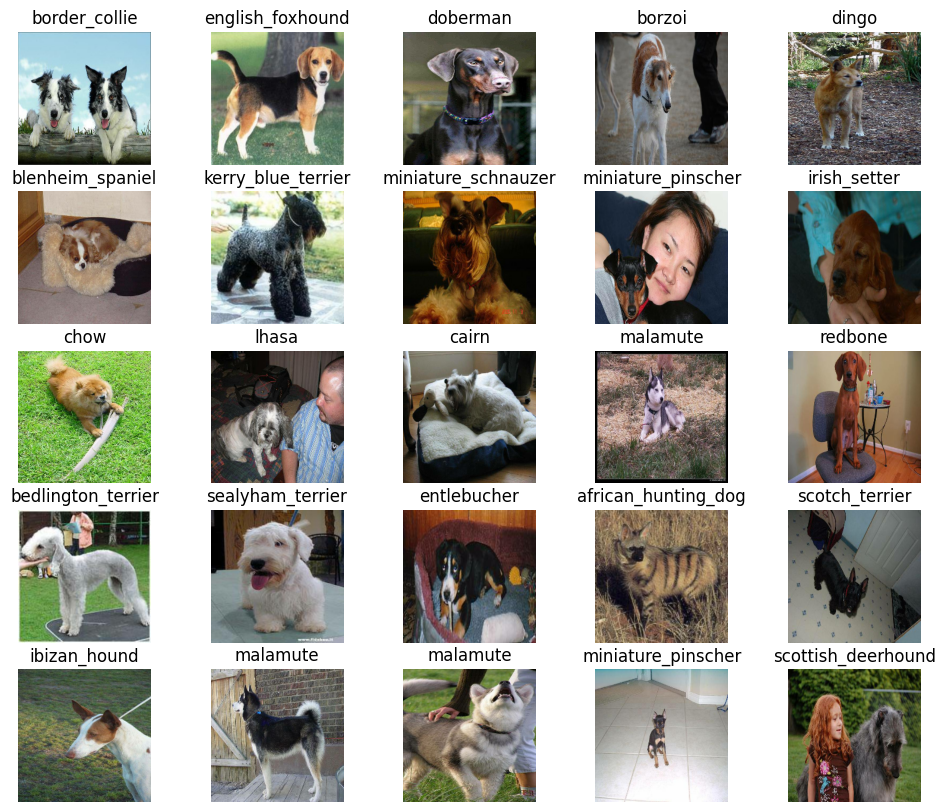

In [51]:
# Try the plotting
train_images, train_labels = next(train_data.as_numpy_iterator())
show_25_images(train_images, train_labels)

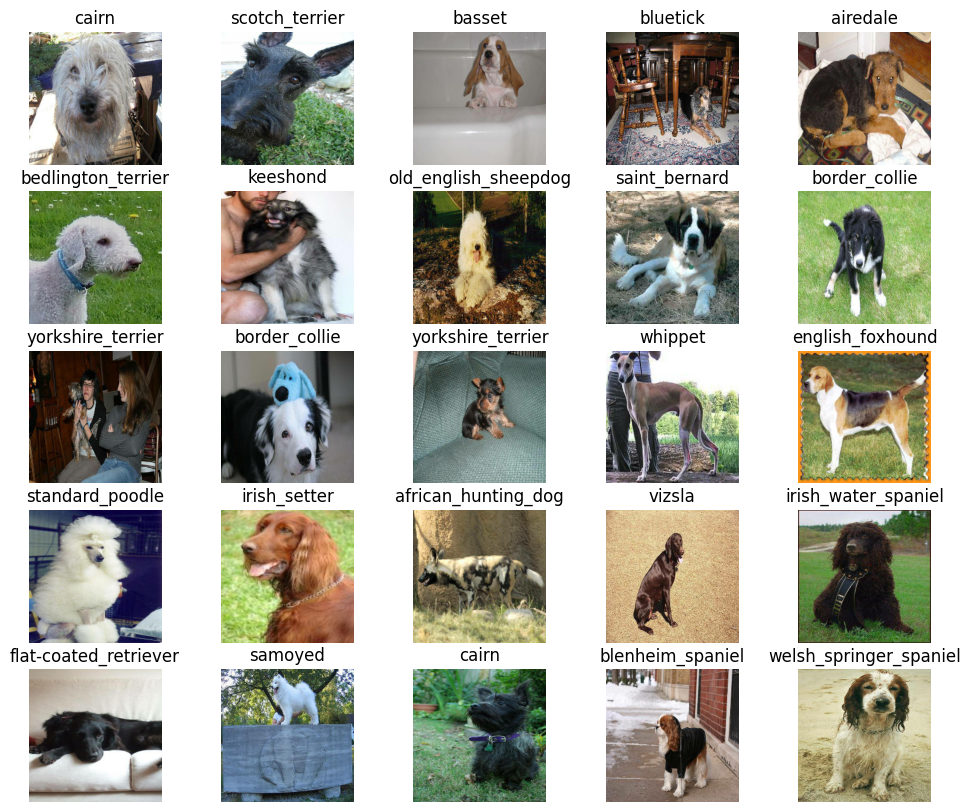

In [52]:
# Visualize validation dataset
val_images, val_labels = next(val_data.as_numpy_iterator())
show_25_images(val_images, val_labels)

## Build a Model
Define things before building a model.
1. The input shape (image shape in the form of Tensors) of the model
2. The output shape (image labels in the form of Tensors) of the model
3. The URL of the model to use

**Note:** most of the time you don't need to build a model from the scratch, there are plenty of pre-trained model on [TensorFLow Hub](https://www.kaggle.com/models?tfhub-redirect=true) per your needs.


In [52]:
# Setup input shape to the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3] # batch, height, width, color channels
# Setup output shape of the model
OUTPUT_SHAPE = len(unique_breeds)
# Setup model URL from TensorFlow Hub